# Example Hystersis Measurement

Hysteresis measurements are standard way to measure antiparrallel polarization switching in ferroelectric capacitors. To conduct a measurement, a simple triangle wave is applied to the sample and the current response measured. The measured current is then integrated to create the classic hysteresis loop. 

This notebook will go through the steps of running a measurement with PIEC. We choose the hysteresis measurement, because we can apply it to a model ferroelectric device (see our simulation folder). This means you can run this notebook completely virtually, and without any testing equipment. Hysteresis measurements are also quite simple, requiring only an oscilloscope and waveform generator. 



## Imports
We begin by importing the instrument drivers we need (in this case virtual versions of an awg and oscilloscope).
Then we import the measurement we are conducting (in this case a HysteresisLoop)

In [1]:
from piec.drivers.oscilloscope.virtual_oscilloscope import VirtualScope
from piec.drivers.awg.virtual_awg import VirtualAwg
from piec.measurement.discrete_waveform import HysteresisLoop


## Seting up the Instruments
Next we have to tell PIEC what the instruments we are using are. If you are using actual instruments you would feed in the GBIP port, but in this case we can just say 'VIRTUAL' because we are running a simulation.

In [2]:
awg = VirtualAwg('VIRTUAL') #Normally you would put the GPBID of your AWG in place of 'VIRTUAL"
osc = VirtualScope('VIRTUAL') #Normally you would put the GPBID of your oscilloscope in place of 'VIRTUAL"

## Measurement Parameters
We bigein by defining the measurement parameters. These will vary between measurements and can be seen by looking at individual measurement objects. 

In [5]:
### VARIABLE DEFINITIONS ###

path = r"your\default\save\directory" # path to save data

voltage = 1.0 # voltage amplitude of the applied triangle wave (V)
frequency = 1.0e6 # frequency of the applied triangle wave (Hz)
voltage_scale = 1 # scale of one y division on the oscilloscope (V), needs to be small enough to be sensitive to the response, but not so small that the signal clips
n_cycles = 2 # how many full voltage cycles to apply, it is good to have at least two to check that successive loops are giving the same response

area = 3.14*(5e-6)**2 # area of the measured capacitor (m^2), used to convert from charge to polarization

time_offset = 0 # time between the trigger and the start of the voltage response (s), not used if automatic_timeshift=True

show_plots = True
save_plots = True
automatic_timeshift = False

## Defining the Measurement
Then we pass the measurement parameters into the measurement object and run!

Running experiment for hysteresis measurement...
Oscilloscope configured.
[OPTIONAL SKIP] initialize is not available on VirtualAwg — skipping.
AWG initialized.
AWG configured.
Capturing waveform of type hysteresis for 1e-06 seconds...
Getting waveform for channel: 1
Applying waveform to virtual sample...
Waveform captured.
Waveform applied and captured.
Waveform data saved to your\default\save\directory\0_hysteresis_1p0V_1000000Hz.csv
Waveform saved.


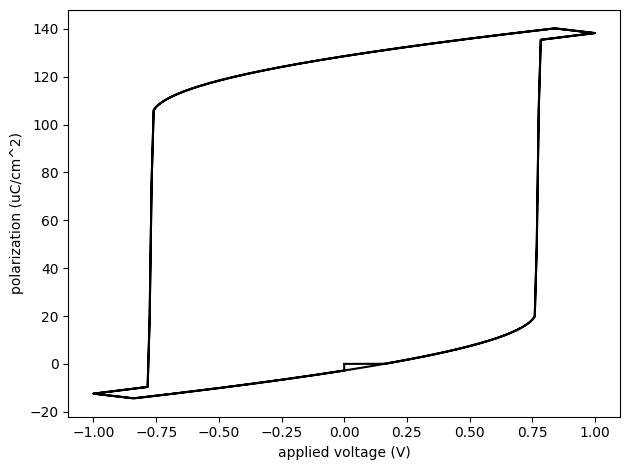

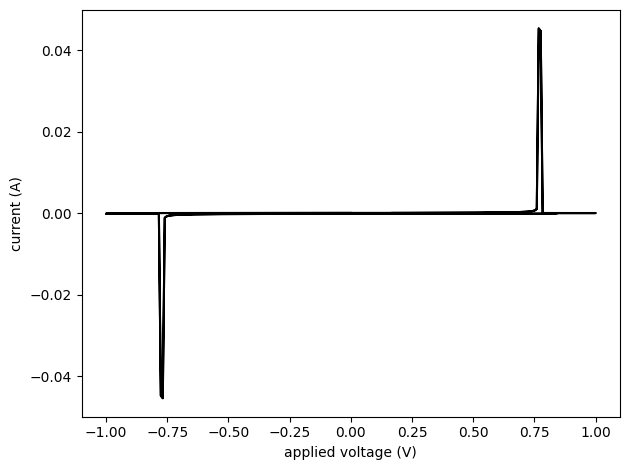

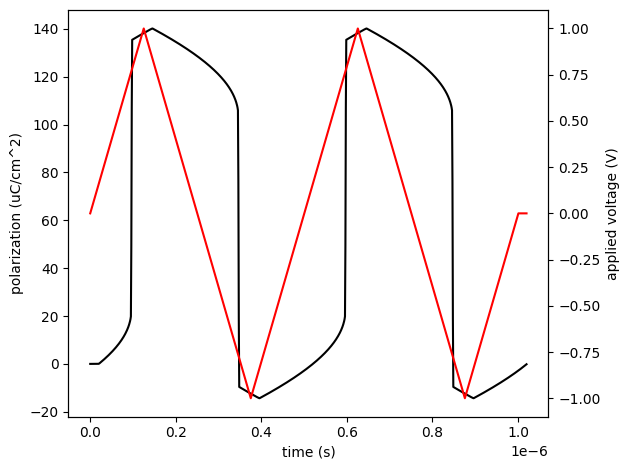

Analysis succeeded, updated your\default\save\directory\0_hysteresis_1p0V_1000000Hz.csv
Analysis complete.
Experiment complete.


In [6]:
experiment = HysteresisLoop(awg, osc, # initialize the experiment object with specified attributes
                            amplitude=voltage, frequency=frequency,
                            v_div=voltage_scale, n_cycles=n_cycles,
                            area=area, time_offset=time_offset,
                            show_plots=show_plots, save_plots=save_plots,
                            save_dir=path, auto_timeshift=automatic_timeshift)

# run the experiment, this will save raw data in the specified directory, update the raw data with analysis, and generate plots
experiment.run_experiment()